In [44]:
from pathlib import Path
import importlib

BASE_DIR = Path.cwd().resolve()
MODULE_PATH = BASE_DIR.parent / "offline-detection" / "main.py"

offline_detection = importlib.machinery.SourceFileLoader(
    "offline-detection", str(MODULE_PATH)
).load_module()

In [45]:
import time
import matplotlib.pyplot as plt
import numpy as np

def msg_callback(msg, end=None):
	print(msg)
	time.sleep(1)

	if end is True: print("Done!")

def handle_report(news, **kwargs):
	global predictions
	predictions = news["predictions"]

	bardata = np.unique(predictions, return_counts=True)
	bar = plt.bar(bardata[0], bardata[1])

	plt.bar_label(bar)
	plt.xticks(ticks=[-1, 0, 1, 2], labels=[None, "Normal", "Anomaly", None])
	plt.title("Predictions of the pipeline")
	plt.show()



Starting pipeline execution...



Preprocessing...



Finished preprocessing.



Obtaining model...



Finished modeling.



Predicting...



Predictions created.



Evaluating results...


Evaluation Metrics:
accuracy: 0.37258347978910367
recall: 0.0
precision: 0.0


/opt/homebrew/Caskroom/miniconda/base/envs/dsc2venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


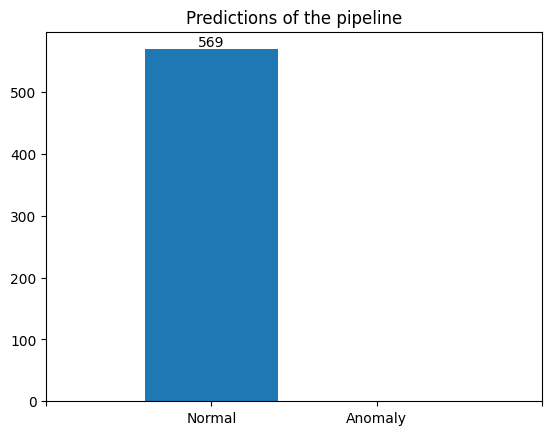



Finished evaluation.



Pipeline execution completed.


Done!


In [46]:
offline_detection.pipeline(
    msg_callback=msg_callback,
    report_callback=handle_report,
    verb=False
)